In [1]:
import pandas as pd

In [2]:
df = pd.read_excel('dados_cerveja.xlsx')
df

,id,temperatura,copo,espuma,cor,classe
0,1,-5,mud,não,escura,weissbier
1,2,-5,mud,sim,escura,weissbier
2,3,-1,pint,não,clara,weissbier
3,4,-1,pint,sim,clara,weissbier
4,5,-5,pint,não,escura,pale-ale
5,6,-5,pint,não,clara,pale-ale
6,7,-5,pint,sim,escura,pale-ale
7,8,-1,mud,não,clara,pilsen
8,9,-5,mud,não,clara,pilsen
9,10,-1,mud,sim,clara,pilsen


In [3]:
# Definir features

features = ['temperatura','copo','espuma','cor']
target_resposta = 'classe' # aprenderá com ela


In [15]:
# Criar o modelo
from sklearn import tree

X = df[features]
y = df[target_resposta]


In [16]:
# Todas as variáveis devem ser do tipo numérico:
# Variáveis dummies:
# mud = 1, pint = 0
# sim = 1, não = 0

X.replace({
    'mud':1,'pint':2,
    'sim':1,'não':0,
    'clara':0,'escura':1
})

/tmp/ipykernel_1192/792094991.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X.replace({


,temperatura,copo,espuma,cor
0,-5,1,0,1
1,-5,1,1,1
2,-1,2,0,0
3,-1,2,1,0
4,-5,2,0,1
5,-5,2,0,0
6,-5,2,1,1
7,-1,1,0,0
8,-5,1,0,0
9,-1,1,1,0


In [18]:
model = tree.DecisionTreeClassifier()

X = X.replace({
    'mud':1,'pint':2,
    'sim':1,'não':0,
    'clara':0,'escura':1
})
model.fit(X=X, y=y)

/tmp/ipykernel_1192/1051471621.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.replace({


DecisionTreeClassifier()

[Text(0.5555555555555556, 0.875, 'copo <= 1.5\ngini = 0.653\nsamples = 12\nvalue = [3, 5, 4]\nclass = pilsen'),
 Text(0.3333333333333333, 0.625, 'temperatura <= -3.0\ngini = 0.408\nsamples = 7\nvalue = [0, 5, 2]\nclass = pilsen'),
 Text(0.4444444444444444, 0.75, 'True  '),
 Text(0.2222222222222222, 0.375, 'cor <= 0.5\ngini = 0.444\nsamples = 3\nvalue = [0, 1, 2]\nclass = weissbier'),
 Text(0.1111111111111111, 0.125, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]\nclass = pilsen'),
 Text(0.3333333333333333, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 0, 2]\nclass = weissbier'),
 Text(0.4444444444444444, 0.375, 'gini = 0.0\nsamples = 4\nvalue = [0, 4, 0]\nclass = pilsen'),
 Text(0.7777777777777778, 0.625, 'temperatura <= -3.0\ngini = 0.48\nsamples = 5\nvalue = [3, 0, 2]\nclass = pale-ale'),
 Text(0.6666666666666667, 0.75, '  False'),
 Text(0.6666666666666666, 0.375, 'gini = 0.0\nsamples = 3\nvalue = [3, 0, 0]\nclass = pale-ale'),
 Text(0.8888888888888888, 0.375, 'gini = 0.0\nsamples = 2\nv

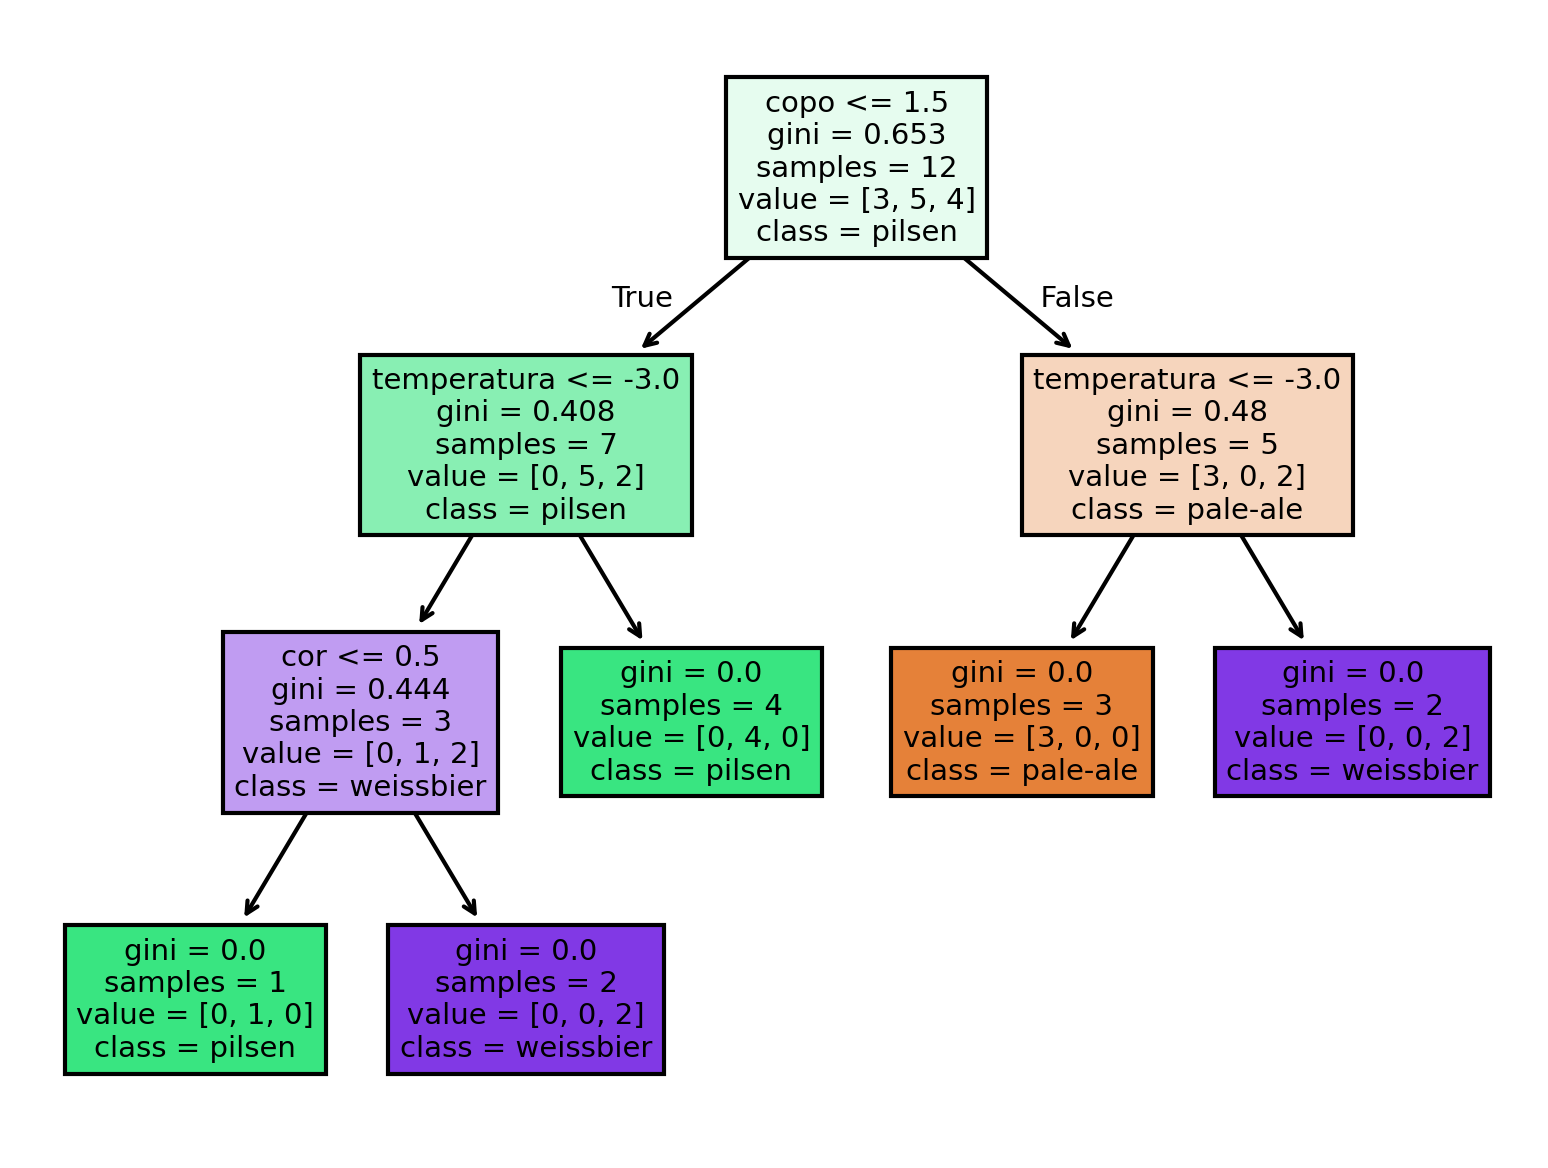

In [21]:
# Mostrar a árvore
import matplotlib.pyplot as plt

plt.figure(dpi=300)

tree.plot_tree(model, feature_names=features,
               class_names=model.classes_,
               filled=True)

In [ ]:
# Definir ponto de corte em faixas, por exemplo, no caso da idade, pode ser melhor para não tornar o modelo tão exaustivo

In [ ]:
# Exemplo de como realizar a predição:
# proba = arvore.predict_proba([[1,1,1,1]])[0]
# pd.Series(proba, index=model.classes_)